### **Dataset Loading & Preprocessing for Fourier Analysis**

In [1]:
import numpy as np
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load filled dataframe for pre-processing and analysis
van_df = pd.read_csv(
    '/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather_Combined/Vancouver_2015_2024_daily_filled.csv',
    sep=',',
    parse_dates=['Date/Time'],
)

# Ensure Date/Time column is read as a df index (D = daily frequency)
van_df = van_df.set_index('Date/Time').asfreq('D')

# Next we will create a specific dataframes for analysis
fourier_df = van_df.copy()


Mounted at /content/drive


### **Discrete Fourier Transform (DFT) Analysis**

In [2]:
import numpy as np
import pandas as pd

# (1) Extract the signal and basic parameters
signal = fourier_df['Mean Temp (°C)'].values    # Array of sample values
N = signal.size                                 # Number of samples
fs = 1.0                                        # Sampling frequency (1 sample/day)
days_per_year = 365.25                          # To convert frequency units
time_index = fourier_df.index                   # Index for plotting

# (2) Compute the DFT (real-valued signal)
X = np.fft.rfft(signal)                         # DFT coefficients (one-sided)
freq_cpd = np.fft.rfftfreq(N, d=1/fs)           # Frequency per bin (cycles per day)
freq_cpy = freq_cpd * days_per_year             # Convert to cycles per year (easier to read)

# (3) Single-Sided Amplitude Spectrum
# Normalize raw amplitude per bin
amplitude = np.abs(X) / N                       # Half of energy on +ve side
# Calculate single-sided amplitude (multiply appropriate bins by 2)
ss_amplitude = amplitude.copy()
ss_amplitude[1:] *= 2                           # N = 3653, odd number of bins

# (4) Summarize relevant numbers
fr_cpd = fs / N                                 # frequency resolution (cycles/day)
nyquist_cpd = fs / 2                            # Nyquist frequency (cycle/day)

print(f'--DFT Number Summary--')
print(f'Number of Samples (N): {N} samples')
print(f'Sampling Frequency (fs): {fs} samples/day')
print(f'Frequency Resolution (fr): {fr_cpd:.6f} cycles/day = {fr_cpd*days_per_year:.6f} cycles/year')
print(f'Nyquist Frequency: {nyquist_cpd:.3f} cycles/day = {nyquist_cpd*days_per_year:.3f} cycles/year')
print(f'Number of Bins = {len(freq_cpd)}')


--DFT Number Summary--
Number of Samples (N): 3653 samples
Sampling Frequency (fs): 1.0 samples/day
Frequency Resolution (fr): 0.000274 cycles/day = 0.099986 cycles/year
Nyquist Frequency: 0.500 cycles/day = 182.625 cycles/year
Number of Bins = 1827


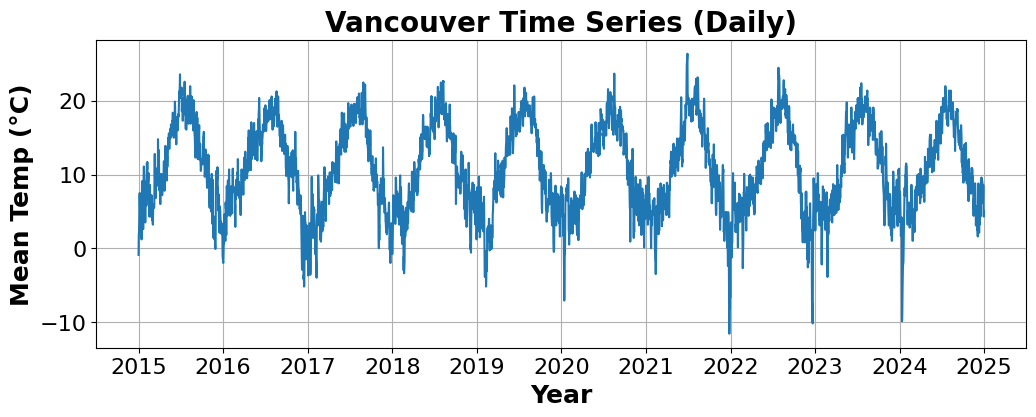

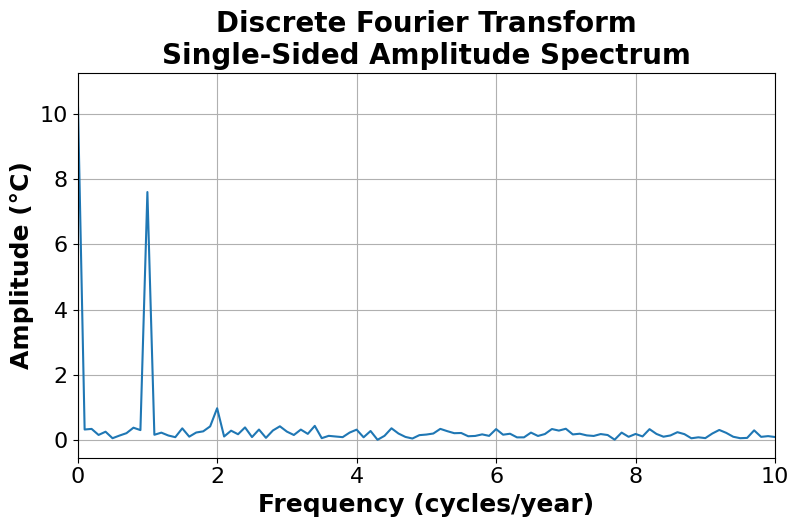

In [3]:
import matplotlib.pyplot as plt

# (5) Plot time series and amplitude spectrum
plt.figure(figsize=(12,4))
plt.plot(time_index, signal)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Year', fontweight='bold', fontsize=18)
plt.ylabel('Mean Temp (°C)', fontweight='bold', fontsize=18)
plt.title('Vancouver Time Series (Daily)', fontweight='bold', fontsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(freq_cpy, ss_amplitude)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)
plt.xlim(0, 10)                                     # Show annual & semiannual cycles
plt.xlabel('Frequency (cycles/year)', fontweight='bold', fontsize=18)
plt.ylabel('Amplitude (°C)', fontweight='bold', fontsize=18)
plt.title('Discrete Fourier Transform\nSingle-Sided Amplitude Spectrum', fontweight='bold', fontsize=20)
plt.grid(True)
plt.show()


In [5]:
# (6) Find dominant peaks
# Sort amplitudes from largest to smallest and remove 0 bin amplitude
sorted_index = np.argsort(ss_amplitude)[::-1]        # Sorts in descending order
sorted_index = [i for i in sorted_index if i != 0]   # Removes 0 index from list
top_k = 15                                           # Only selects top 8 amplitudes

print('\nTop 15 Spectral Peaks:')

# Loop over top frequencies and extract their information
for index in sorted_index[:top_k]:
    f_cpy = freq_cpy[index]                           # Frequency in cycle/year
    f_cpd = freq_cpd[index]                           # Frequency in cycle/day
    amp_val = ss_amplitude[index]                     # Frequency strength in °C

    # Convert frequency into period in days & years (period = days/years per cycle)
    period_days = 1.0 / f_cpd
    period_years = period_days / days_per_year

    print(f'Bin: {index:3d} | Frequency: {f_cpy:6.3f} cycles/year| Amplitude: {amp_val:6.3f} | Period: {period_days:6.1f} days ({period_years:.1f} years)')



Top 15 Spectral Peaks:
Bin:  10 | Frequency:  1.000 cycles/year| Amplitude:  7.604 | Period:  365.3 days (1.0 years)
Bin:  20 | Frequency:  2.000 cycles/year| Amplitude:  0.980 | Period:  182.7 days (0.5 years)
Bin:  34 | Frequency:  3.400 cycles/year| Amplitude:  0.440 | Period:  107.4 days (0.3 years)
Bin:  29 | Frequency:  2.900 cycles/year| Amplitude:  0.427 | Period:  126.0 days (0.3 years)
Bin:  19 | Frequency:  1.900 cycles/year| Amplitude:  0.425 | Period:  192.3 days (0.5 years)
Bin:  24 | Frequency:  2.400 cycles/year| Amplitude:  0.393 | Period:  152.2 days (0.4 years)
Bin:   8 | Frequency:  0.800 cycles/year| Amplitude:  0.384 | Period:  456.6 days (1.3 years)
Bin:  45 | Frequency:  4.499 cycles/year| Amplitude:  0.366 | Period:   81.2 days (0.2 years)
Bin:  15 | Frequency:  1.500 cycles/year| Amplitude:  0.364 | Period:  243.5 days (0.7 years)
Bin: 128 | Frequency: 12.798 cycles/year| Amplitude:  0.362 | Period:   28.5 days (0.1 years)
Bin:  70 | Frequency:  6.999 cycles/

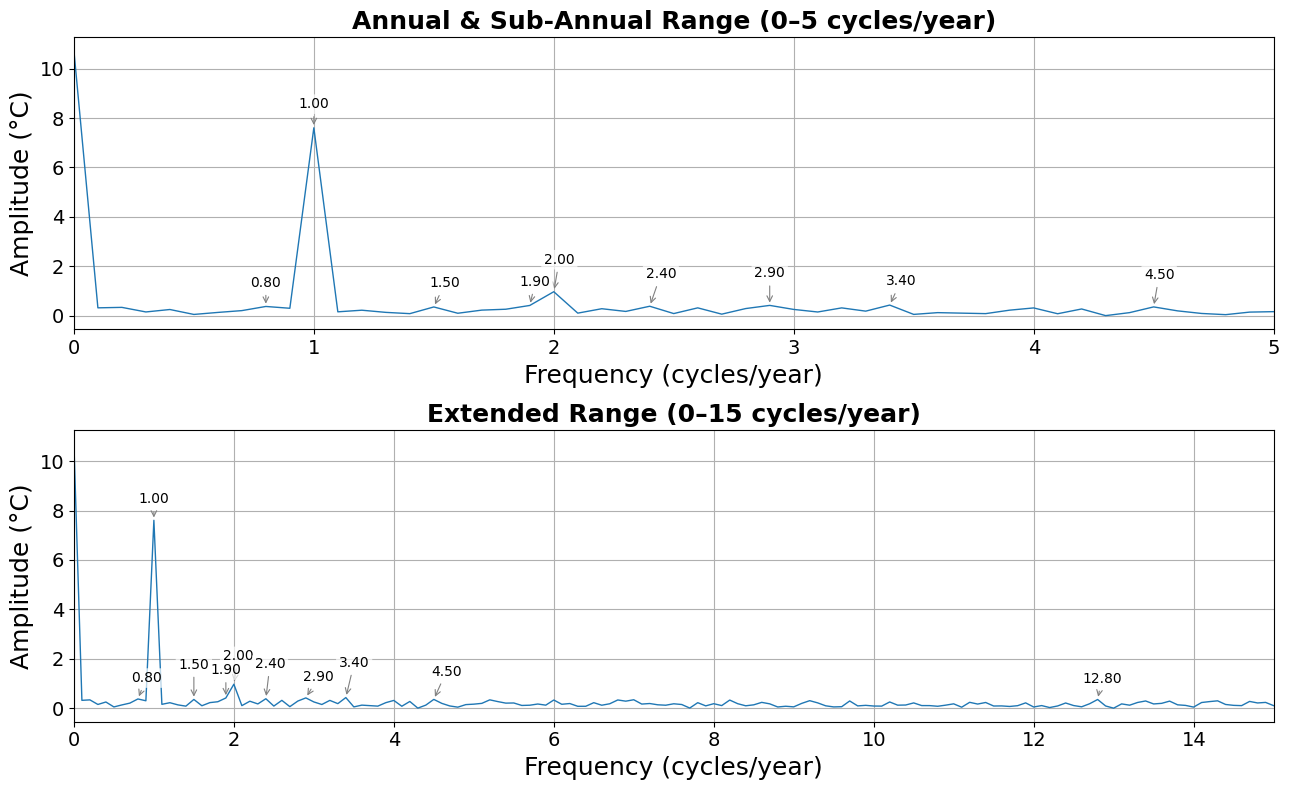

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Plot amplitude spectrum with top peak labels

fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# Top plot (0-5 cycles/year)
axs[0].plot(freq_cpy, ss_amplitude, linewidth=1)
axs[0].set_xlim(0, 5)
axs[0].set_xticks([0,1,2,3,4,5])
axs[0].set_xlabel('Frequency (cycles/year)', fontsize=18)
axs[0].set_ylabel('Amplitude (°C)', fontsize=18)
axs[0].set_title('Annual & Sub-Annual Range (0–5 cycles/year)', fontweight='bold', fontsize=18)
axs[0].grid(True)
axs[0].tick_params(axis='both', which='major', labelsize=14)

# Label top 10 peaks for the top plot
annot_count = 10
y_offset_points = 12
for idx, i in enumerate(sorted_index[:annot_count]):
    f = freq_cpy[i]
    amp = ss_amplitude[i]
    if f <= 5:
        # Shift slightly for dense clusters
        xoff = 0 + (idx % 3) * 4
        axs[0].annotate(f'{f:.2f}',
                        xy=(f, amp),
                        xytext=(xoff, y_offset_points + (idx % 2)*6),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=10,
                        rotation=0,
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0),
                        arrowprops=dict(arrowstyle='->', lw=0.8, color='gray'))

# Bottom plot (0-15 cycles/year)
axs[1].plot(freq_cpy, ss_amplitude, linewidth=1)
axs[1].set_xlim(0, 15)
axs[1].set_xticks([0,2,4,6,8,10,12,14])
axs[1].set_xlabel('Frequency (cycles/year)', fontsize=18)
axs[1].set_ylabel('Amplitude (°C)', fontsize=18)
axs[1].set_title('Extended Range (0–15 cycles/year)', fontweight='bold', fontsize=18)
axs[1].grid(True)
axs[1].tick_params(axis='both', which='major', labelsize=14)

# Label top 10 peaks for the bottom plot
for idx, i in enumerate(sorted_index[:10]):
    f = freq_cpy[i]
    amp = ss_amplitude[i]
    if f <= 15:
        xoff = 0 + (idx % 4) * 3
        axs[1].annotate(f'{f:.2f}',
                        xy=(f, amp),
                        xytext=(xoff, 10 + (idx % 3)*5),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=10,
                        rotation=0,
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0),
                        arrowprops=dict(arrowstyle='->', lw=0.8, color='gray'))

plt.subplots_adjust(hspace=0.35, top=0.95)
plt.tight_layout()
plt.show()


In [7]:
# (7) Inverse transformation check (check to ensure transformation worked)
recreate_signal = np.fft.irfft(X, n=N)
MSE = np.mean((signal - recreate_signal)**2)
print(f'\nInverse-DFT Reconstruction MSE = {MSE:.3e}')


Inverse-DFT Reconstruction MSE = 2.988e-29



Reconstructed Signal MSE = 6.26766e+00


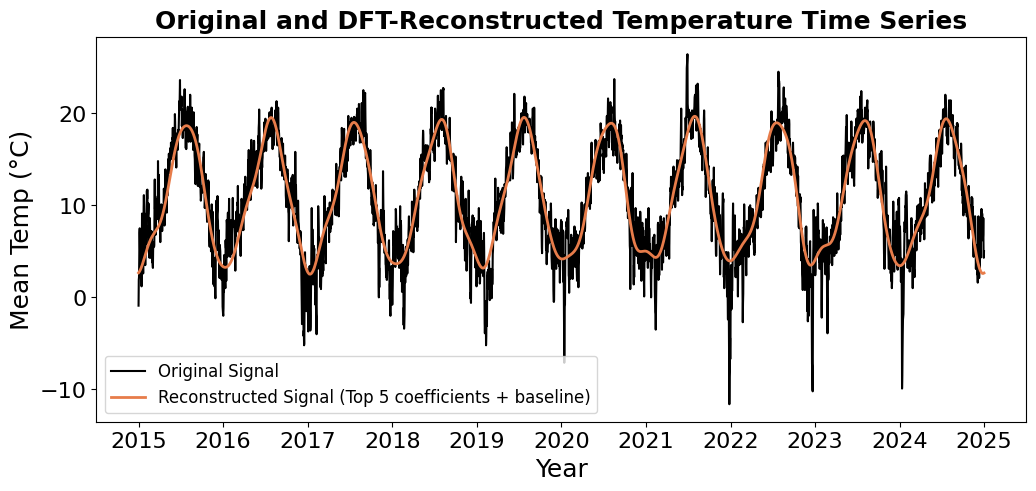

In [8]:
# (8) Reconstruct signal using only top k spectral peaks
K = 5                                              # Use top 5 spectral peaks
recon_bins = sorted_index[:K]                      # Extract top K peaks

# Create empty array same shape as X (the FFT output)
recon_spectrum = np.zeros_like(X, dtype=complex)

# Add mean and top K peak into empty array
recon_spectrum[0] = X[0]                            # Keeps mean spectral peak
for i in recon_bins:
    recon_spectrum[i] = X[i]

# Perform inverse rFFT to reconstruct time series
recon_signal = np.fft.irfft(recon_spectrum, n=N)

# Compute MSE of reconstructed signal vs raw signal
recon_MSE = np.mean((signal - recon_signal)**2)
print(f'\nReconstructed Signal MSE = {recon_MSE:.5e}')

# Plot results
plt.figure(figsize=(12,5))
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)
plt.plot(time_index, signal, color='black', label='Original Signal', alpha=1)
plt.plot(time_index, recon_signal, color='#E77C4A', label=f'Reconstructed Signal (Top {K} coefficients + baseline)', linewidth=2)
plt.title('Original and DFT-Reconstructed Temperature Time Series', fontweight='bold', fontsize=18)
plt.xlabel('Year', fontsize=18)
plt.ylabel('Mean Temp (°C)', fontsize=18)
plt.legend(fontsize=12)
plt.show()
